In [4]:
import os 
print(os.getcwd())

c:\Users\Shrusti\OneDrive\Desktop\Project DA\notebooks


In [15]:
import os
os.listdir("../data/cleaned")

['financial_dataset_cleaned.csv']

In [16]:
import pandas as pd

df = pd.read_csv("../data/cleaned/financial_dataset_cleaned.csv")

In [18]:
df.head()

,year,quarter,company_id,revenue,expenses,operating_income,net_income,assets,liabilities,equity,...,global_economic_score,inflation_rate,exchange_rate,interest_rate,audit_flag,fraud_flag,market_shock_flag,policy_change_flag,target_revenue_next_qtr,target_anomaly_class
0,2015,1,CMP_001,229991.3061,212058.6555,17932.65064,10592.371030,531737.3791,171875.3048,359862.0743,...,0.212339,2.272775,64.585113,4.433938,0,0,0,0,232953.1703,0
1,2015,2,CMP_001,214801.5217,190523.2287,24278.29303,7500.653613,515383.5079,260626.2319,254757.2760,...,0.965632,6.658781,67.615344,2.781377,0,0,0,0,202861.8164,0
2,2015,3,CMP_001,231901.9884,185517.5190,46384.46937,36708.803230,705013.5932,365679.3493,339334.2438,...,0.921874,1.619448,64.899572,2.361818,0,0,0,0,226367.1549,0
3,2015,4,CMP_001,213291.5593,186390.8956,26900.66373,9867.709016,458385.1648,318465.2818,139919.8829,...,0.771270,1.518313,68.961643,2.926952,0,0,0,0,220837.2080,0
4,2016,1,CMP_001,210824.8234,185755.8298,25068.99357,9124.900899,690475.5294,452182.1340,238293.3953,...,0.040434,5.974640,62.772271,5.514692,0,0,0,0,210554.5643,0


In [20]:
df["period"] = df["year"].astype(str) + " Q" + df["quarter"].astype(str)

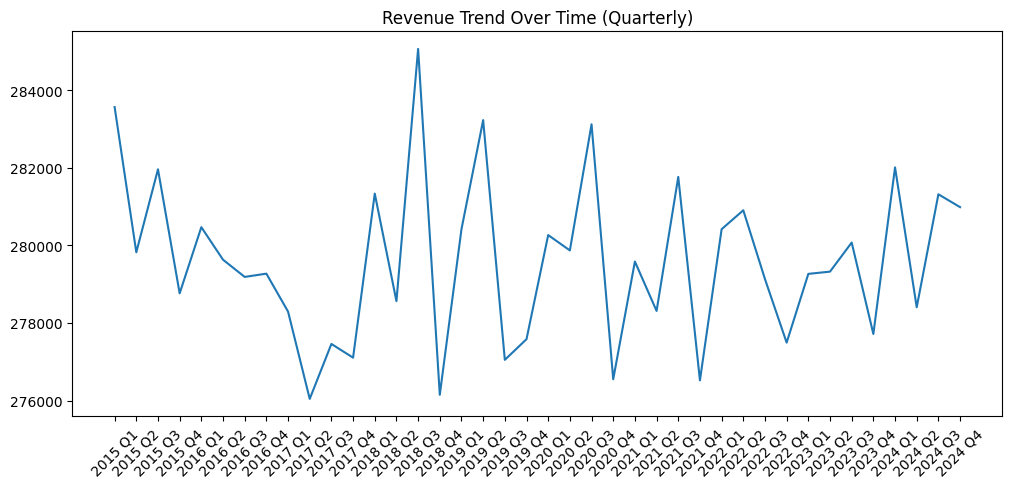

In [21]:
import matplotlib.pyplot as plt

trend = df.groupby("period")["revenue"].mean()

plt.figure(figsize=(12,5))
plt.plot(trend)
plt.xticks(rotation=45)
plt.title("Revenue Trend Over Time (Quarterly)")
plt.show()

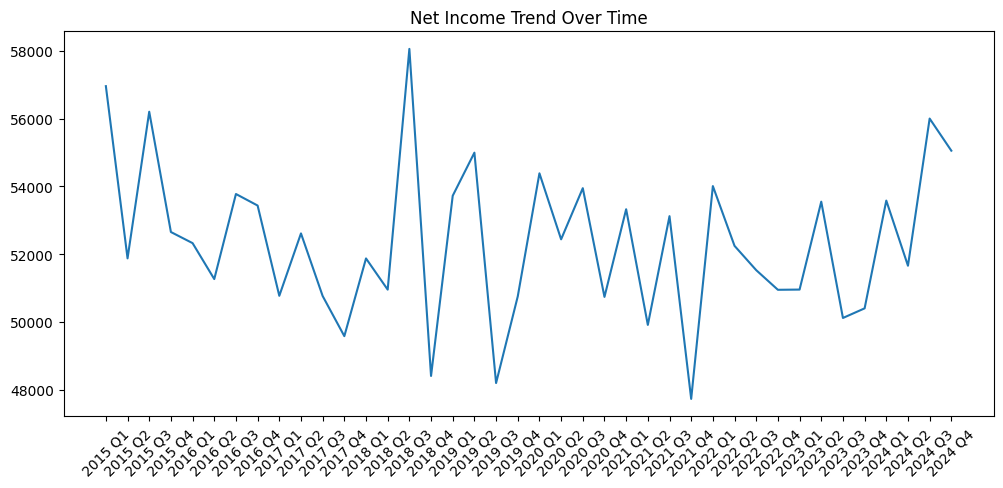

In [22]:
profit_trend = df.groupby("period")["net_income"].mean()

plt.figure(figsize=(12,5))
plt.plot(profit_trend)
plt.title("Net Income Trend Over Time")
plt.xticks(rotation=45)
plt.show()

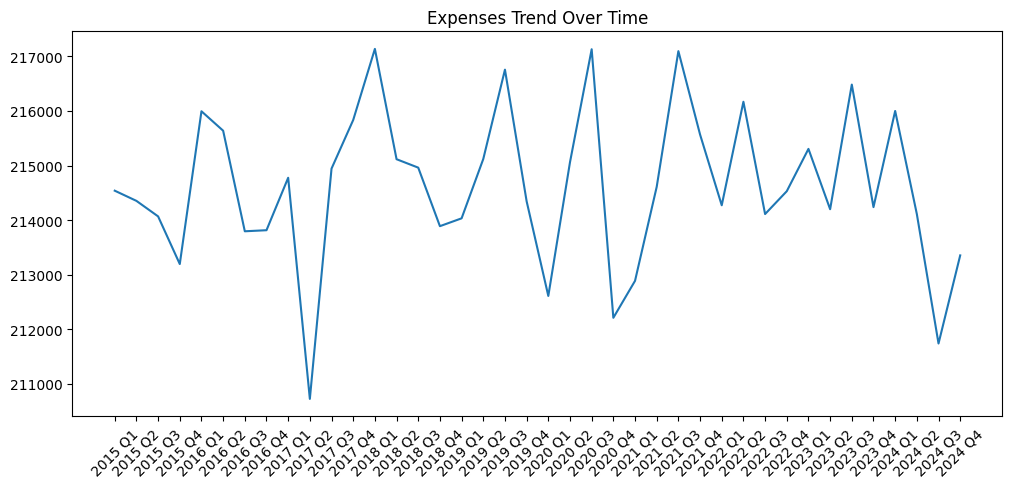

In [23]:
expense_trend = df.groupby("period")["expenses"].mean()

plt.figure(figsize=(12,5))
plt.plot(expense_trend)
plt.title("Expenses Trend Over Time")
plt.xticks(rotation=45)
plt.show()

In [24]:
df.groupby("company_id")["net_income"].mean().sort_values(ascending=False)

company_id
CMP_009    159191.891158
CMP_017    158697.354038
CMP_039    134218.060007
CMP_004    132940.274257
CMP_023    129642.886381
CMP_010    119784.451485
CMP_015    118094.310612
CMP_044    114096.246524
CMP_035    110848.315958
CMP_019    103458.294840
CMP_040     91326.478123
CMP_008     87050.588698
CMP_025     74514.073846
CMP_045     70449.006879
CMP_046     69146.605891
CMP_050     68844.542576
CMP_031     65313.957357
CMP_047     62794.599572
CMP_029     58746.373295
CMP_005     58123.928815
CMP_028     56467.435298
CMP_002     48295.063434
CMP_014     47421.359240
CMP_036     47163.019235
CMP_027     46879.194065
CMP_041     35928.804904
CMP_034     31749.102396
CMP_030     30745.487699
CMP_021     30267.149622
CMP_006     29651.532192
CMP_042     28038.034077
CMP_048     26358.175548
CMP_012     24269.464022
CMP_038     20117.633644
CMP_026     17372.814794
CMP_022     17149.113940
CMP_033     16144.110475
CMP_001     12436.162328
CMP_032     12397.265433
CMP_024     10

In [27]:
df["revenue"] = df["revenue"].round(2)
df["expenses"] = df["expenses"].round(2)
df["net_income"] = df["net_income"].round(2)

In [29]:
df = df.round(2)

Create Profitability Metric

In [30]:
df["profit_margin"] = (df["net_income"] / df["revenue"]) * 100

Revenue vs Net Income Relationship

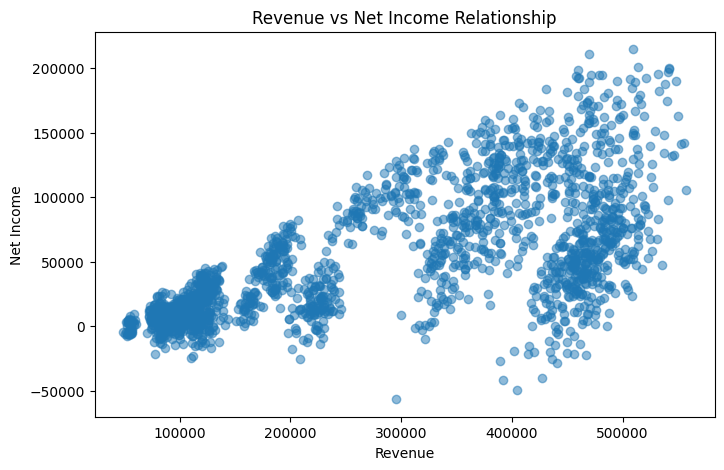

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["revenue"], df["net_income"], alpha=0.5)

plt.xlabel("Revenue")
plt.ylabel("Net Income")
plt.title("Revenue vs Net Income Relationship")
plt.show()

Company-level profitability

In [32]:
company_profit = df.groupby("company_id")[["revenue", "net_income"]].mean()
company_profit["profit_margin"] = (company_profit["net_income"] / company_profit["revenue"]) * 100

company_profit.sort_values("profit_margin", ascending=False)

,revenue,net_income,profit_margin
company_id,,,
CMP_019,288521.63325,103458.29600,35.858072
CMP_004,371242.03475,132940.27450,35.809596
CMP_017,447418.67750,158697.35400,35.469542
CMP_040,259257.28075,91326.47750,35.226196
CMP_035,318896.76500,110848.31625,34.759938
CMP_039,396779.11350,134218.05975,33.826896
CMP_047,190333.58875,62794.59950,32.991864
CMP_009,494751.07025,159191.89100,32.176159
CMP_044,389308.37500,114096.24625,29.307421


Risk detection

In [33]:
risk_companies = company_profit[company_profit["profit_margin"] < 5]

risk_companies

,revenue,net_income,profit_margin
company_id,,,
CMP_013,83307.97900,-782.86250,-0.939721
CMP_016,100282.10050,2420.43925,2.413630
CMP_018,116524.29200,750.19650,0.643811
CMP_020,54967.45550,-449.22975,-0.817265
CMP_037,86974.51350,3296.14075,3.789778
CMP_049,127941.42975,548.10100,0.428400


In [36]:
print(df.columns.tolist())


['year', 'quarter', 'company_id', 'revenue', 'expenses', 'operating_income', 'net_income', 'assets', 'liabilities', 'equity', 'cash_flow', 'eps', 'roe', 'roa', 'debt_to_equity', 'stock_price', 'volume_traded', 'news_sentiment_score', 'social_media_buzz', 'sector_trend_index', 'global_economic_score', 'inflation_rate', 'exchange_rate', 'interest_rate', 'audit_flag', 'fraud_flag', 'market_shock_flag', 'policy_change_flag', 'target_revenue_next_qtr', 'target_anomaly_class', 'period', 'profit_margin']
